# Algúnos métodos XAI para imágenes
Óscar Niño Robles

## 1: Guided Integrated Gradients

### Explicación del método

Para entender el método, como es una variante de *Integrated Gradients* vamos a recordar este método primero en unas líneas.

#### Contextualización: método *Integrated Gradients (IG)*

Recordamos que este método sirve para "repartir" la predicción entre los píxeles de la imagen. Podemos así diferenciar los píxeles más y menos importantes. La idea es la siguiente: Imagina que una red neuronal dice que una foto es un "Incendio". El método IG intenta asignar un número a cada píxel. Si el píxel es de color naranja (fuego), tendrá una **atribución** alta. Si es un píxel del cielo azul que no ayudó a la decisión, su atribución será cercana a cero.

El método se realiza de la siguiente manera, se considera la imagen a la que le queramos aplicar el método de explicabilidad y por otro lado consideramos una imagen que la consideramos sin información (una imagen completamente en negro, blanco o simplemente con píxeles aleatorios). Parametrizamos una recta que va desde la imagen sin información (la asumimos completamente negra) hasta la imagen original.

La atribución o importancia de cada píxel será la diferencia de los píxeles en las dos imágenes por la integral en la recta del gradiente del píxel. Esta integral sirve de promedio del gradiente en la recta. Además está presente el axioma de completitud, que dice que la suma de todas las atribuciones de todos los píxeles, el resultado es exactamente igual a la diferencia entre la predicción de la imagen real y la de la imagen negra. Es decir, no se pierde nada de "importancia" por el camino.

Expresemos ahora todo lo dicho anteriormente de manera matemática. Lo primero que tenemos son las dos imágenes



*   $x$ : La imagen de entrada de la que queremos obtener explicacbilidad
*   $x'$ : La imagen sin información que vamos a considerar para el modelo, una imagen completamente en negro por ejemplo.

Parametrizamos entonces la recta $γ(\alpha) = x' + \alpha(x - x'), \alpha \in [0,1]$. Definimos entonces la atribución de un pixel $i$ como:

$$IG_i(x) = \int_{\alpha=0}^{1} \frac{\partial F(\gamma(\alpha))}{\partial \gamma_i(\alpha)} \frac{\partial \gamma_i(\alpha)}{\partial \alpha} d\alpha$$


donde $F(x)$ es la probabilidad o la puntuación de confianza (score) que el modelo asigna a una clase específica para la entrada $x$.



Esto es de forma teórica, pues en la práctica se elige un número de pasos y se aproxima la integral con la suma de Riemman, es decir,

$$IG_i(x) \approx \frac{1}{m} \sum_{k=1}^{m} \left. \left[ \frac{\partial F(\gamma(\alpha))}{\partial \gamma_i(\alpha)} \cdot \frac{\partial \gamma_i(\alpha)}{\partial \alpha} \right] \right|_{\alpha = \frac{k}{m}}$$

donde $m$ es el número de pasos. Evidentemente a mayor número de pasos, menos error se produce en la aproximación.

#### Motivación del método

Aunque el método IG tiene sentido intuitivamente, hay veces que se produce ruido o algo así como unos "falsos positivos" (salen como importantes píxeles que realmente no lo son). Esto se produce ya que en ese método, los píxeles se van coloreando poco a poco todos por igual hasta llegar a la imagen original. Durante estas "coloraciones parciales" la imagen está difusa y grisacea y quizás el modelo se confunde y se dispara el gradiente de un píxel de forma desorbitada porque piensa que es importante para la predicción (como la imagen está grisacea el modelo busca cualquier mínima cosa reconocible). Aunque luego al seguir coloreando la imagen el modelo detecte que hay otros píxeles importantes y que ese no lo era tanto, como su gradiente se disparó en un paso, al promediar todos los gradientes de todos los pasos sigue saliendo en media un píxel con atribución elevada aunque es un pixel que no es importante. A esto se le llama **ruido**

Esta fue la principal motivación del método *Guided Integrated Gradients*, usar el propio IG pero corregir esa aparación de ruido que se creaba al usar una línea recta para llevar la imagen completamente negra a su imagen original.

#### Descripción del método

La idea del método es similar a la de IG. Las diferencias ahora es que el modelo no sigue una línea recta para llegar al modelo original y no se van transformando todos los píxeles por igual.

Se seleccionan una cantidad (por ejemplo el 10%) de los píxeles cuyo gradiente en valor absoluto es mínimo. Estos se "colorean" un poco, se retiene el valor para luego calcular la atribución del píxel y se sigue ejecutando el método, calcular los gradientes, colorear los que tengan menor gradiente en valor absoluto y guardar el valor para luego promediar los gradientes. Evidentemente el algoritmo llega a su fin, pues cuando unos píxeles ya se han transformado en los de la imagen original se dejan de tener en cuenta.

**¿Por qué se toman los menores gradientes en valor absoluto?** Precisamente para evitar el ruido que comentabamos antes. Recordemos que el ruido se formaba porque la imagen estaba difusa y el modelo se "confundía" y usaba cualquier píxel que mínimamente le pareciera que podría usar para dar la predicción aunque fuera un píxel aleatorio del fondo. Ese gradiente en esa etapa se disparaba de forma desorbitada y luego al promediar los gradientes, la atribución seguía siendo alta. Al ir coloreando los píxeles que el modelo ya tiene claro que no son importantes (los que tienen menor gradiente en valor absoluto) la imagen se va definiendo más y es más díficil que el modelo se confunda  y piense que un píxel no es importante sí que es importante por el simple hecho de que la imagen esté difusa. En cambio, los píxeles que sí que eran importantes los seguirá considerando como tal aunque la imagen esté definida. De esta forma conseguimos que el gradiente no se dispare en píxeles aleatorios y evitamos el ruido.


Vemos entonces que no hay un camino fijo como en IG, el camino se va adaptando y creando sobre la marcha siguiendo los gradientes. A esto se le llama *adaptive path methods*.

Detallemos cómo se va seleccionando el camino: Como en  IG, el camino ($c$) empieza en una imagen sin información ($X^B$) y acaba en la imagen original de la que se desea obtener explicabilidad ($X^I$). Pero ahora no movemos todos los píxeles por igual como antes, vamos decidiendo que píxeles se mueven en cada paso. En cada paso, buscamos un subconjunto  $\mathbb{S}$ de píxeles, con el menor gradiente en valor absoluto posible (de entre los que no están ya devueltos a la imagen original). El siguiente paso del camino viene determinado por mover solo aquellos píxeles en  $\mathbb{S}$ más cerca al píxel correspondiente de la imagen original. El camino acaba cuando todos los píxeles se han devuelto a su intensidad original. De forma matemática, sea $F: R^N \rightarrow R$ una función de  $X = \{x_1, ..., x_N\}$. El camino de IG guidado $GIG_{(X^S, X^E, F)}$, se define en base a un punto de comienzo $(X^S)$, otro final $(X^E)$, y el vector de dirección de cada punto de la curva:
$$\left[
\begin{array}{l}
X^S = X^B \\
X^E = X^I \\
\frac{\partial \gamma_i^F(\alpha)}{\partial \alpha} =
\begin{cases}
x_i^I - x_i^B & \text{, si } i \in \mathbb{S}, \\
0 & \text{, en caso contrario.}
\end{cases}
\end{array}
\right.
$$$\mathbb{S}$ se calcula para cada punto de la curva $c$, y contiene los píxeles con gradiente de menor valor absoluto (de entre los que no tienen todavía su intensidad original). Matemáticamente, $$\mathbb{S} = \{i | \forall j : y_i \le y_j\} \equiv \arg\min_i(Y)$$$$y_i =
\begin{cases}
\left| \frac{\partial F(X)}{\partial x_i} \right| & \text{, si } i \in \{j | x_j \neq x_j^I\} \\
\infty & \text{, en caso contrario.}
\end{cases} $$


Al final para obtener la atribución de cada píxel, de forma teórica es con la integral de los valores de los gradientes. Pero en realidad se aproxima con una suma de Riemman.

#### Pseudo-código

$$\begin{array}{l}
\hline
\textbf{Algoritmo 1 } \text{Cálculo de Guided IG No Acotado} \\
\hline
\textbf{Entradas:} \\
\quad X^I, \text{ Ejemplo de entrada} \\
\quad X^B, \text{ Línea base (Baseline)} \\
\quad T > 0, \text{ Número de pasos} \\
\quad grad(x), \text{ Gradiente de la función} \\
\quad p \in (0, 1], \text{ Fracción objetivo de características a cambiar en cada paso} \\
\\
\textbf{Inicializar:} \\
\quad d_{total} \leftarrow ||X^B - X^I||_1 \\
\quad x \leftarrow X^B \\
\quad attr \leftarrow \text{zeros}(\text{tamaño de } X^I) \\
\\
\textbf{for } t \leftarrow 1 \textbf{ to } T \textbf{ do} \\
\quad y \leftarrow grad(x) \\
\quad \textbf{repeat} \\
\quad \quad y_i \leftarrow \infty, \quad \forall i \mid x_i = X_i^I \\
\quad \quad d_{target} \leftarrow d_{total}\left(1 - \frac{t}{T}\right) \\
\quad \quad d_{current} \leftarrow ||x - X^I||_1 \\
\\
\quad \quad \textbf{if } d_{target} = d_{current} \textbf{ then} \\
\quad \quad \quad \textbf{break} \\
\quad \quad \textbf{end if} \\
\\
\quad \quad \triangleright \text{Asignar a } S \text{ la fracción } p \text{ de características con menor gradiente:} \\
\quad \quad S \leftarrow \{i \mid |y_i| \le \text{fraction}(p, |y|)\} \\
\quad \quad d_S \leftarrow \sum_{i \in S} |x_i - X_i^I| \\
\quad \quad \delta \leftarrow \frac{d_{current} - d_{target}}{d_S} \\
\quad \quad temp \leftarrow x \\
\\
\quad \quad \textbf{if } \delta > 1 \textbf{ then} \\
\quad \quad \quad x_i \leftarrow X_i^I, \quad \forall i \in S \\
\quad \quad \textbf{else} \\
\quad \quad \quad x_i \leftarrow (1 - \delta)x_i + \delta X_i^I, \quad \forall i \in S \\
\quad \quad \textbf{end if} \\
\\
\quad \quad y_i = 0, \quad \forall i \text{ donde } y_i = \infty \qquad \triangleright \text{evitar mul. por } \infty \\
\quad \quad attr_i \leftarrow attr_i + (x_i - temp_i)y_i, \quad \forall i \in S \\
\\
\quad \textbf{until } \delta \le 1 \\
\textbf{end for} \\
\\
\textbf{return } attr \\
\hline
\end{array}$$

### Ejemplo práctico (cacatúa)

Cargamos las librerias

In [ ]:
import warnings
warnings.filterwarnings("ignore")



import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import keras
import matplotlib as mpl


from PIL import Image
from IPython.display import Image as Image_IP
from IPython.display import display

from matplotlib import pyplot as plt
from matplotlib import pylab as P
from skimage.segmentation import mark_boundaries
from skimage import segmentation as sk_segmentation
from skimage.segmentation import felzenszwalb, quickshift

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')
%cd 'drive/MyDrive/SAAA_2026'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SAAA_2026


Leemos la imagen

In [ ]:
def read_image(file_name):
  image = tf.io.read_file(file_name)
  image = tf.io.decode_jpeg(image, channels=3)
  image = tf.image.convert_image_dtype(image, tf.float32)
  image = tf.image.resize_with_pad(image, target_height=224, target_width=224)
  return image

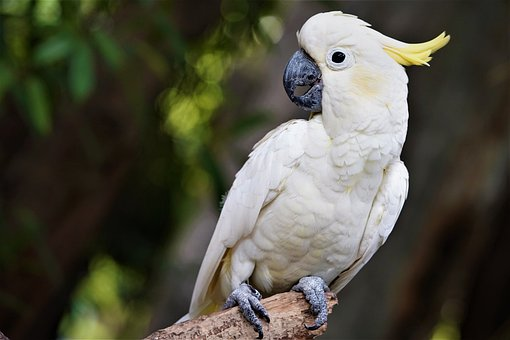

In [ ]:
img_path = './cockatoo.jpeg'
image_tensor = read_image(img_path)
tf.keras.utils.load_img(img_path)

Descargamos el modelo y hacemos la predicción sobre la imagen

In [ ]:
model = hub.KerasLayer("https://tfhub.dev/google/imagenet/inception_v1/classification/4", trainable=False,name='inception_v1')

# Fijamos el tamaño del batch de entrada para el modelo que acabamos de descargar
model.build([None, 224, 224, 3])

In [ ]:
labels_file = tf.keras.utils.get_file(origin='https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
with open(labels_file) as reader:
  labels = reader.read().splitlines()
imagenet_labels = np.array(labels)

In [ ]:
def top_k_predictions(img, k=3):
  image_batch = tf.expand_dims(img, 0)
  predictions = model(image_batch)
  probs = tf.nn.softmax(predictions, axis=-1)
  top_probs, top_idxs = tf.math.top_k(input=probs, k=k)
  top_labels = imagenet_labels[tuple(top_idxs)]
  return top_labels, top_probs[0]

In [ ]:
pred_label, pred_prob = top_k_predictions(image_tensor)
for label, prob in zip(pred_label, pred_prob):
    print(f'{label}: {prob:0.1%}')

sulphur-crested cockatoo: 99.6%
spoonbill: 0.1%
American egret: 0.0%


Como ya sabíamos el modelo está muy seguro de que es una cacatúa

Veamos de forma rápida  lo que obtenemos con el método IG

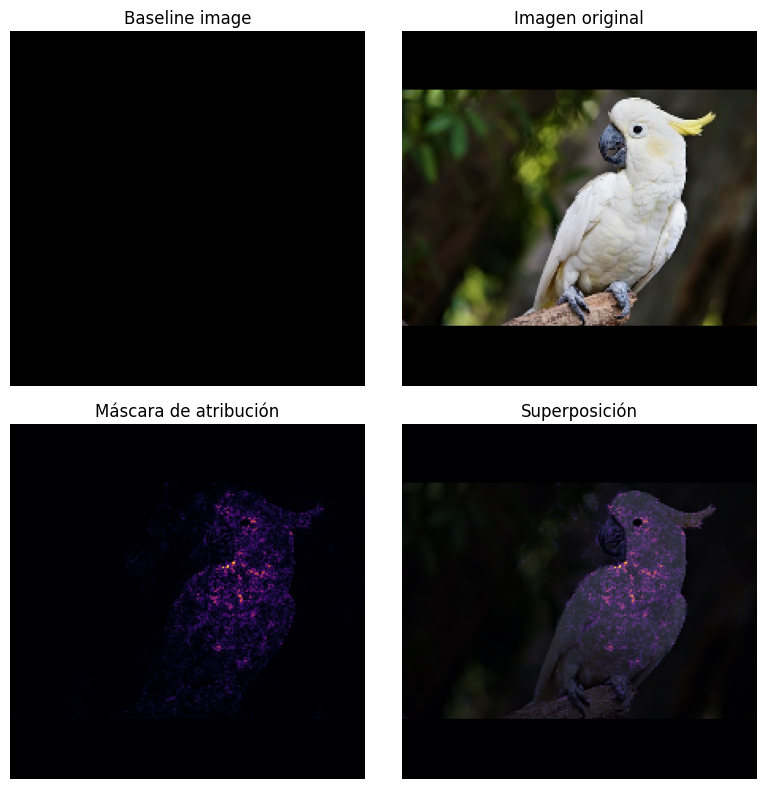

In [ ]:
black_baseline = tf.zeros(shape=(224,224,3))

def interpolate_images(baseline,
                       image,
                       alphas):
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    baseline_x = tf.expand_dims(baseline, axis=0)
    input_x = tf.expand_dims(image, axis=0)
    images = alphas_x * input_x + (1 - alphas_x) * baseline_x
    return images



def compute_gradients(images, target_class_idx):
    with tf.GradientTape() as tape:
        tape.watch(images)
        logits = model(images)
        probs = tf.nn.softmax(logits, axis=-1)[:, target_class_idx]
    return tape.gradient(probs, images)


def integral_approximation(gradients):
    grads = (gradients[:-1] + gradients[1:]) / tf.constant(2.0) # Hacemos un suavizado
    integrated_gradients = tf.math.reduce_mean(grads, axis=0)
    return integrated_gradients

@tf.function
def one_batch(baseline, image, alpha_batch, target_class_idx):
    # Generamos las imágenes
    interpolated_path_input_batch = interpolate_images(baseline=baseline,
                                                       image=image,
                                                       alphas=alpha_batch)

    # Computamos los gradientes
    gradient_batch = compute_gradients(images=interpolated_path_input_batch,
                                       target_class_idx=target_class_idx)
    return gradient_batch

def integrated_gradients(baseline,
                         image,
                         target_class_idx,
                         m_steps=50,
                         batch_size=32):
  # Generamos los valores de alfa
  alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1)

  # Generamos una lista vacío donde almacenaremos el resultado de los batches
  gradient_batches = []

  # Iteramos sobre los valores de alfa y aplicamos el algoritmo sobre un "batch" cada vez
  # usando la función "one_batch"
  for alpha in tf.range(0, len(alphas), batch_size):
    from_ = alpha
    to = tf.minimum(from_ + batch_size, len(alphas))
    alpha_batch = alphas[from_:to]
    gradient_batch = one_batch(baseline, image, alpha_batch, target_class_idx) # one_batch se define aparte
    gradient_batches.append(gradient_batch)

  # Concatenamos los batches de gradientes en un único tensor
  total_gradients = tf.concat(gradient_batches, axis=0)

  # Calculamos los valores medios
  avg_gradients = integral_approximation(gradients=total_gradients)

  # Calculamos el tensor final
  integrated_gradients = (image - baseline) * avg_gradients

  return integrated_gradients



def plot_img_attributions(baseline,
                          image,
                          target_class_idx,
                          m_steps=50,
                          cmap='Reds',
                          overlay_alpha=0.4):

  attributions = integrated_gradients(baseline=baseline,
                                      image=image,
                                      target_class_idx=target_class_idx,
                                      m_steps=m_steps)

  attribution_mask = tf.reduce_sum(tf.math.abs(attributions), axis=-1)

  fig, axs = plt.subplots(nrows=2, ncols=2, squeeze=False, figsize=(8, 8))

  axs[0, 0].set_title('Baseline image')
  axs[0, 0].imshow(baseline)
  axs[0, 0].axis('off')

  axs[0, 1].set_title('Imagen original')
  axs[0, 1].imshow(image)
  axs[0, 1].axis('off')

  axs[1, 0].set_title('Máscara de atribución')
  axs[1, 0].imshow(attribution_mask, cmap=cmap)
  axs[1, 0].axis('off')

  axs[1, 1].set_title('Superposición')
  axs[1, 1].imshow(attribution_mask, cmap=cmap)
  axs[1, 1].imshow(image, alpha=overlay_alpha)
  axs[1, 1].axis('off')

  plt.tight_layout()
  return fig



_ = plot_img_attributions(image=image_tensor,
                          baseline=black_baseline,
                          target_class_idx=90,
                          m_steps=10,
                          cmap=plt.cm.inferno,
                          overlay_alpha=0.2)


Vamos que la máscara se sitúa sobre la cacatúa, como era de esperar

#### GIG

Habiendo visto ya IG de forma rápida, vamos a ver lo que el método de gradientes integrados guiados (GIG). Lo primero es descargar la libreria `saliency` que sabemos que tiene incorporada la `GuidedIG`. Se puede encontrar más información [aquí](https://github.com/PAIR-code/saliency/blob/master/saliency/core/guided_ig.py)

In [ ]:
!pip install saliency

In [ ]:
import saliency.core as saliency

Sabemos que la clase de la cacatúa tiene el índice 90, si no lo supieramos pues lo buscamos

In [ ]:
LABEL = 'sulphur-crested cockatoo'
idx_cockatoo = np.where(imagenet_labels==LABEL)[0][0]
idx_cockatoo

np.int64(90)

Cargamos el modelo y el índice en un diccionario

In [ ]:
mis_argumentos = {
    'model': model,
    'class_id': 90
}

La función que vamos a utilizar, requiere que vayamos calculando los gradientes así que creamos una función para ello. Por comodidad, le metemos un argumento extra que no se utiliza, pero lo recibe por la forma de al función `Get_Mask`

In [ ]:
def funcion_gradientes_inception(images, call_model_args, expected_keys):
    """
    Esta función recibe las imágenes de la librería Saliency,
    las pasa por tu modelo y devuelve los gradientes.
    """
    # Extraemos el modelo y la clase de los argumentos
    modelo = call_model_args['model']
    class_id = call_model_args['class_id']

    # Convertimos el array de numpy a un Tensor de TensorFlow
    images_tensor = tf.cast(images, tf.float32)


    with tf.GradientTape() as tape:

        tape.watch(images_tensor)
        predicciones = modelo(images_tensor)

        # Aislamos la puntuación (score) de la clase que nos interesa explicar
        target_score = predicciones[:, class_id]

    # Calculamos el gradiente de la puntuación objetivo con respecto a la imagen
    gradientes = tape.gradient(target_score, images_tensor)

    # Devolvemos el resultado en el formato exacto que pide la librería Saliency
    return {saliency.INPUT_OUTPUT_GRADIENTS: gradientes.numpy()}

Con esta función ya definida, pasamos a llamar a las funciones `GuidedIG()` y `GetMask`

In [ ]:
# Inicamos el método Guided IG
guided_ig = saliency.GuidedIG()


# Creamos la imagen base (baseline).
imagen_base_negra = tf.zeros(shape=(224,224,3))

# Calculamos la máscara de explicabilidad
mascara_guided_ig = guided_ig.GetMask(
    x_value=image_tensor,
    call_model_function=funcion_gradientes_inception,
    call_model_args=mis_argumentos,
    x_baseline=imagen_base_negra,
    x_steps=10,
    max_dist=1.0,
    fraction=0.2
)

print("¡Máscara calculada con éxito! Forma:", mascara_guided_ig.shape)

¡Máscara calculada con éxito! Forma: (224, 224, 3)


Una vez calculada la máscara, procedemos a pintarla igual que hicimos con IG

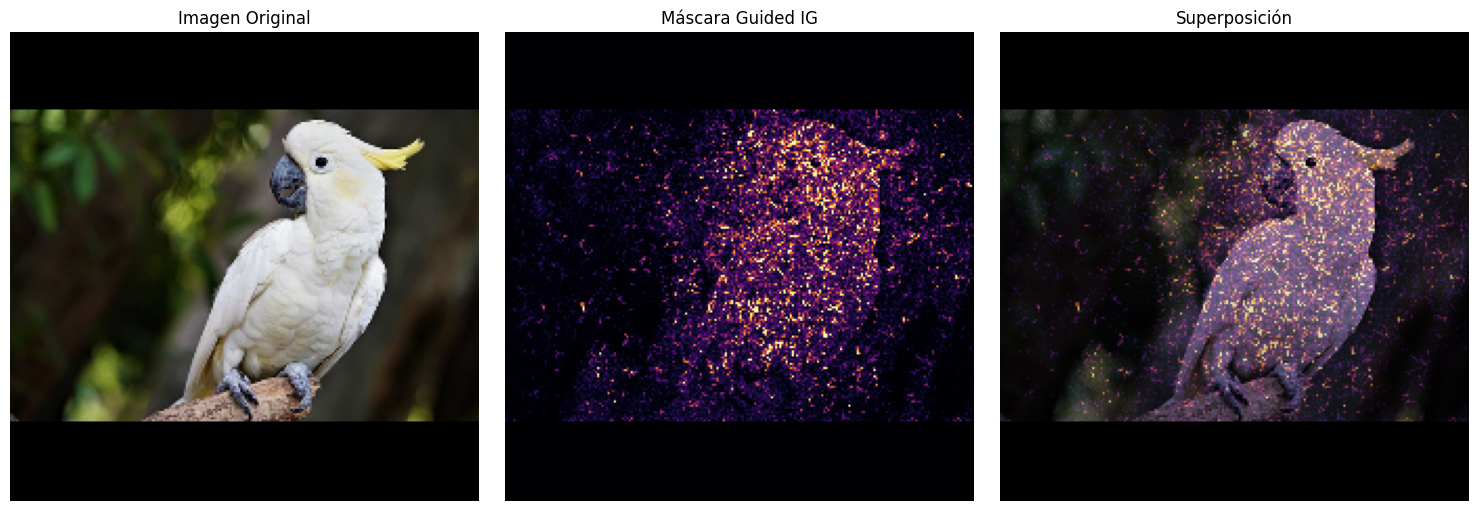

In [ ]:
# Procesar la máscara "cruda" a una escala de grises en 2D
# Esta función toma el valor absoluto y colapsa los canales de color
mascara_gris = saliency.VisualizeImageGrayscale(mascara_guided_ig)

# Asegurarnos de que la imagen original está en formato (224, 224, 3) para Matplotlib
# (Si image_tensor tiene el batch dimension (1, 224, 224, 3), se lo quitamos con [0])
img_visualizar = image_tensor[0].numpy() if len(image_tensor.shape) == 4 else image_tensor.numpy()


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: Imagen Original ---
axs[0].imshow(img_visualizar)
axs[0].set_title('Imagen Original')
axs[0].axis('off')

# --- Panel 2: Máscara (Mapa de Calor) ---
axs[1].imshow(mascara_gris, cmap='inferno')
axs[1].set_title('Máscara Guided IG')
axs[1].axis('off')

# --- Panel 3: Superposición ---
axs[2].imshow(img_visualizar)
axs[2].imshow(mascara_gris, cmap='inferno', alpha=0.6) # alpha controla la transparencia
axs[2].set_title('Superposición')
axs[2].axis('off')

plt.tight_layout()
plt.show()

Vemos que la mascara tiene más fuerza en la cacatúa, cosa que tiene sentido, al igual que en IG. Vamos a imprimir ahora los resultados con GIG y IG para hacer una comparativa, usando 10 pasos en ambos métodos

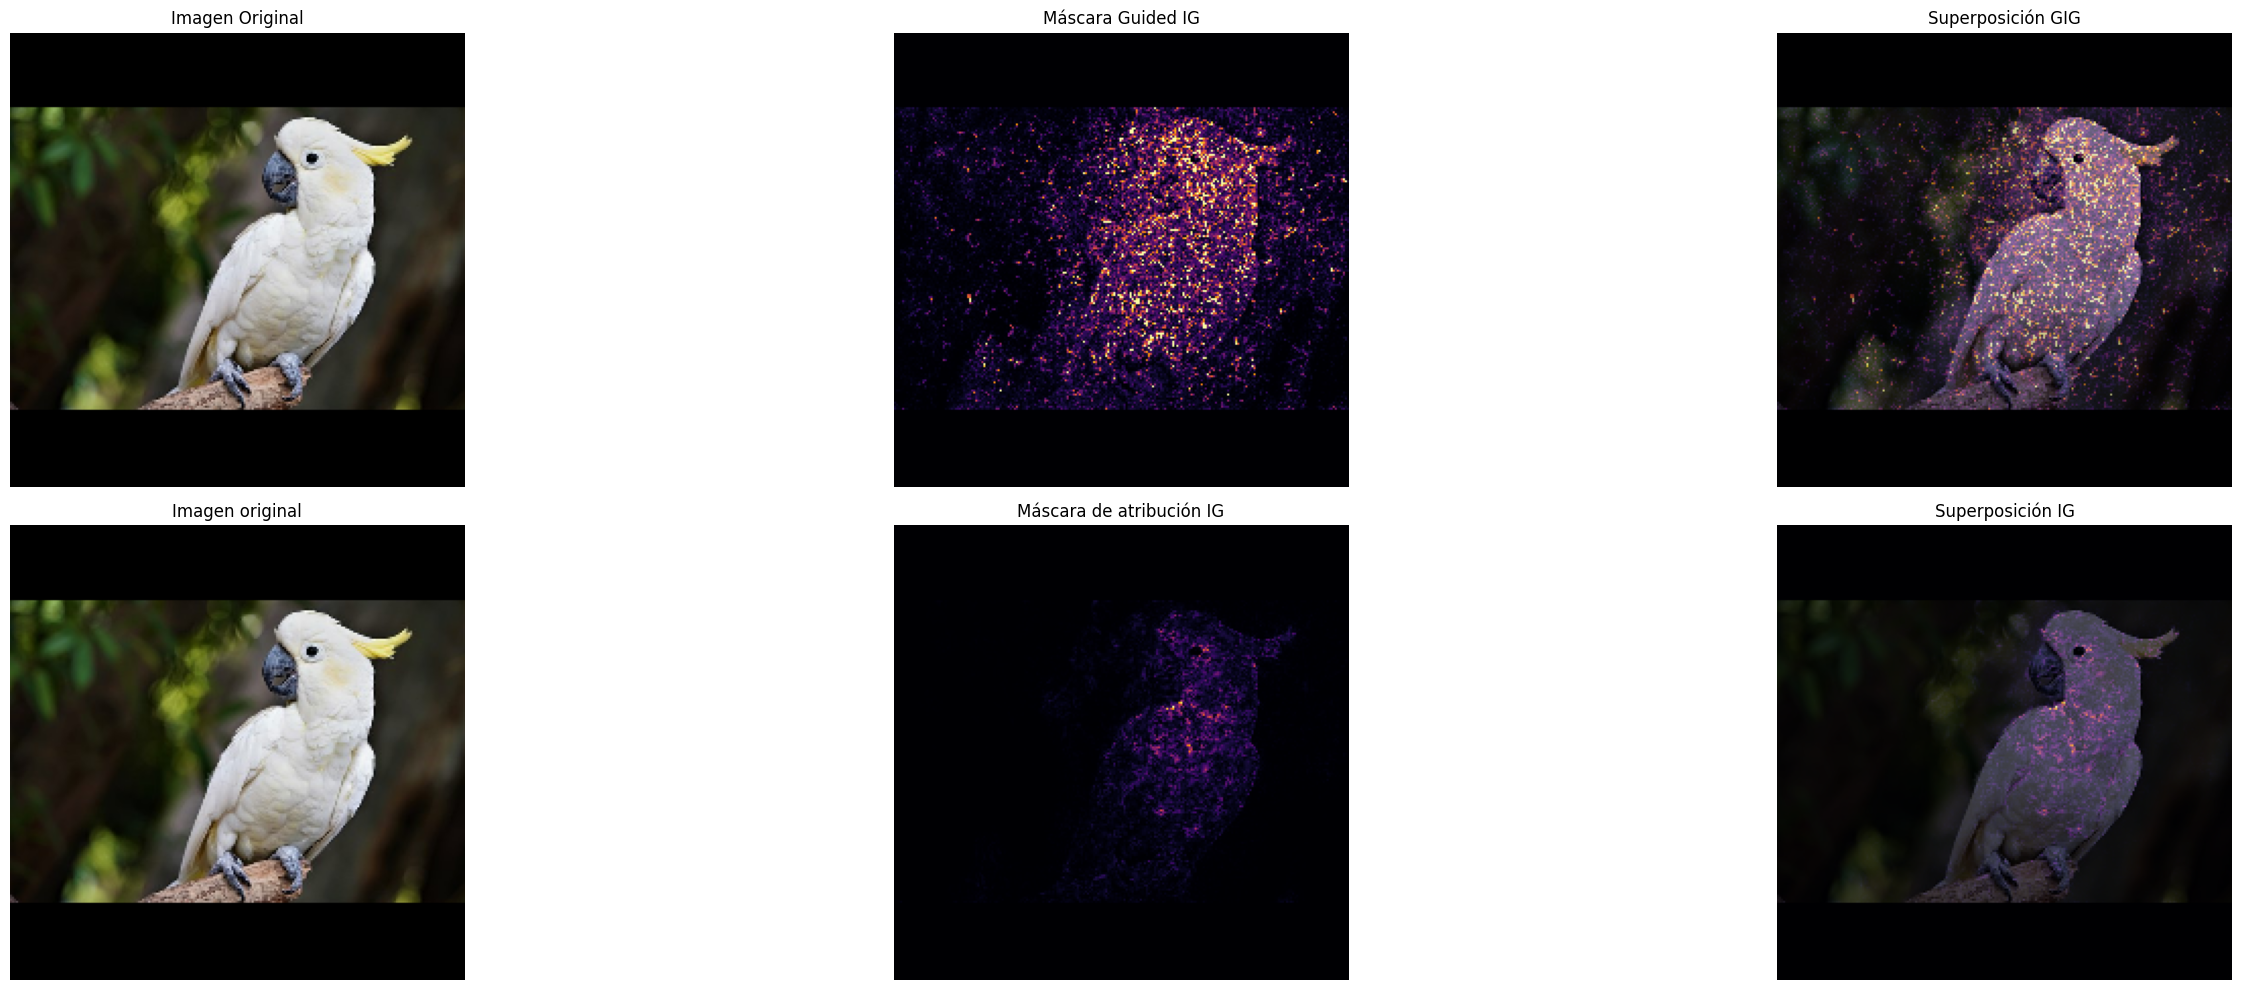

In [ ]:
attributions = integrated_gradients(baseline=black_baseline,
                                      image=image_tensor,
                                      target_class_idx=90,
                                      m_steps=10)

attribution_mask = tf.reduce_sum(tf.math.abs(attributions), axis=-1)



fig, axs = plt.subplots(nrows=2, ncols=3, squeeze=False,figsize=(30,10))

# --- Panel 1: Imagen Original ---
axs[0,0].imshow(img_visualizar)
axs[0,0].set_title('Imagen Original')
axs[0,0].axis('off')

# --- Panel 2: Máscara (Mapa de Calor) ---
# Usamos el mapa de color 'inferno' o 'hot' para ese efecto de "iluminación"
axs[0,1].imshow(mascara_gris, cmap='inferno')
axs[0,1].set_title('Máscara Guided IG')
axs[0,1].axis('off')

# --- Panel 3: Superposición ---
axs[0,2].imshow(img_visualizar)
axs[0,2].imshow(mascara_gris, cmap='inferno', alpha=0.6) # alpha controla la transparencia
axs[0,2].set_title('Superposición GIG')
axs[0,2].axis('off')




axs[1, 0].set_title('Imagen original')
axs[1, 0].imshow(img_visualizar)
axs[1, 0].axis('off')

axs[1, 1].set_title('Máscara de atribución IG')
axs[1, 1].imshow(attribution_mask, cmap='inferno')
axs[1, 1].axis('off')

axs[1, 2].set_title('Superposición IG')
axs[1, 2].imshow(attribution_mask, cmap='inferno')
axs[1, 2].imshow(img_visualizar, alpha=0.3)
axs[1, 2].axis('off')





plt.tight_layout()
plt.show()

Vemos que ambos señalan a la cacatúa, la única diferencia apreciable es que en GIG es más brillante. Igualmente conviene recordar que la mayor diferencia entre los modelos erradicaba en la eliminación de ruido, pero como con IG nuestra imagen no presenta ruido, no podemos comprobar este efecto.

### Ventajas e incovenientes

Tras todo lo visto, y como recapitulación, queda claro lo siguiente:


*   **Ventajas**: El método GIG da mejores resultados que IG, pues elimina el ruido que se puede generar al ir en linea recta usando IG
*   **Desventajas**: Evidentemente, es más complejo computacionalmente hablando. Mientras que IG el camino está decidido y es una simple recta, en GIG ese camino se va actualizando paso a paso, lo que requiere un mayor coste computacional.



## 2: ShapleyCAM

### Explicación del método

Como este método combina las ideas de CAM y de valores Shapley, vamos a recordar en qué consiste cada cosa para entender bien este modelo.

#### Contextualización: Método Grad-CAM

En este método vamos a tomar el gradiente de una función cuya salida es el valor de una de las neuronas de la última capa, pero en este caso la entrada no es la imagen inicial, sino los mapas de activación de la última capa convolucional.

El algoritmo de Grad-CAM puede resumirse en los siguientes pasos:
* Sean $A_k$ los mapas de activación de la última capa convolucional del predictor y sea $y^c$ el valor de la clase de salida para la que queremos tener explicación antes de aplicarle softmax. Calculamos el gradiente de $y^c$ respecto a cada $A_k$ $$\frac{\partial y^c}{\partial A_k}$$
* Para cada mapa de activación $k$, calculamos el valor medio de ese gradiente y lo llamamos $W_k^c$ (sumamos para cada fila $i$ y cada columna $j$ del mapa de activación)
$$\displaystyle W_k^c = \frac{1}{Z} \sum_i\sum_j \frac{\partial y^c}{\partial A_k}$$
* Obtenemos una 'imagen' mediante una combinación lineal de los mapas de activación $A_k$ usando como pesos los $W_k^c$ que hemos obtenido y aplicamos ReLU para llevar a cero los valores negativos $$L^c_{Grad-CAM}= ReLU(\sum_k W_k^c\,A_k)$$
* Puesto que $L^c_{Grad-CAM}$ es una matriz con la misma altura y anchura que los mapas de activación de la última capa convolucional (y, en general, mucho más pequeños que la atura y anchura de la imagen original) al algoritmo termina aumentando la resolución de $L^c_{Grad-CAM}$ al tamaño de la imagen original para poder realizar la superposición de las dos imágenes.



#### Contextualización: Valores Shapley

El valor de Shapley surgió en la teoría de juegos cooperativos, donde se quería repartir un premio entre los jugadores de forma totalmente justa matemáticamente, en base a la contribución marginal de cada jugador en todas las combinaciones posibles.

Es decir, dado un conjunto de jugadores $D$ y la recomensa $U(D)$ se tenía que cumplir lo siguiente


*   Jugador nulo : Si $U(S \cup \{i\}) = U(S)$ para
todo $S \subseteq D \setminus \{i\}$, entonces $\phi(i;U) = 0$.
*   Simetría : Si $U(S \cup \{i\}) = U(S \cup \{j\})$ para todo $S \subseteq D \setminus \{i, j\}$, entonces $\phi(i;U) = \phi(j;U)$.


*   Eficiencia : $\sum_{i \in D} \phi(i;U) = U(D) - U(\emptyset)$.
*  Linealidad : Para las funciones de utilidad $U_1, U_2$ y cualquier $\alpha_1, \alpha_2 \in \mathbb{R}$, $\phi(i; \alpha_1 U_1 + \alpha_2 U_2) = \alpha_1 \phi(i; U_1) + \alpha_2 \phi(i; U_2)$.

Donde  $\phi (i,U)$ es el valor de Shapley del individuo $i$ con la función de recompensas $U$

Se puede demostrar matemáticamente que la única forma de que se cumplan todos estos valores es usar la definición y fórmula que sigue.

Dado un conjunto de jugadores $D$ con $n = |D|$ y una función de utilidad $U$, el **valor de Shapley** para cada jugador $i \in D$ se define como:$$\phi(i;U) = \frac{1}{n} \sum_{k=1}^{n} \binom{n - 1}{k - 1}^{-1} \sum_{\substack{S \subseteq D \setminus \{i\} \\ |S|=k-1}} [U(S \cup \{i\}) - U(S)].$$.


Esto se puede extrapolar a redes neuronales con imágenes, ganando así popularidad en el ámbito, haciendo que la "recompensa" sea el nivel de confianza de la predicción y los "jugadores" sean los píxeles de la imágen. Así, de forma teórica podríamos repartir esa confianza en la predicción entre los píxeles de la imagen ayudando a la explicabilidad de esa predicción. Realmente esto en la práctica es imposible, pues calcular ese número es muy costoso, para ello se usan aproximaciones

#### Motivación del método

Este método surge principalmente porque los métodos como GradCAM se quedan solo en el gradiente, y se intenta modelar todo como si fuera lineal (igual que pasaba con el método IG). Además que los métodos CAM normalmente dependeían de heurísticas y la susencia de una fundación teórica sólida suponen un problema para su desarrollo futuro.

#### Explicación del método

Entendiendo la idea de usar los mapas de atención de GradCAM y lo que simboliza los valores Shapley el método se entiende muy fácil. Primero en el artículo se hace un marco teórico donde se justifica de forma matemática que se pueden utilizar $N$ capas de activación $\{A^i\}_{i=1}^N$  de la red neuronal convolucional como los jugadores de los valores Shapley, para obtener la parte de confianza en la predicción aplicable a cada una.

Una vez hecha esta puntualización, podemos aproximar el valor de Shapley usando polinomios de Taylor. Usando el polinomio de Taylor de primer orden llegaríamos al método GradCAM, pero este método va un poco más allá, usamos Taylor de segundo orden para el cuál necesitamos el cálculo de la matriz hessiana.


Un poco de desarrollo matemático a continuación

 **Notación**: Definamos $X_D \in \mathbb{R}^{1 \times Nd}$ como $X_D := [A^1 | A^2 | \cdots | A^N]$, donde $A^i \in \mathbb{R}^{1 \times d}$. Sea $X^i \in \mathbb{R}^{1 \times Nd}$ el vector con $A^i$ en su ubicación original y ceros en el resto: $X^i := [\vec{0} | \cdots | A^i | \cdots | \vec{0}]$, donde $\vec{0} \in \mathbb{R}^{1 \times d}$. Definamos $X_j \in \mathbb{R}^{1 \times Nd}$ como $X_j := [0, A_j^1, 0 | \cdots | 0, A_j^i, 0 | \cdots | 0, A_j^N, 0]$ reteniendo únicamente el $j$-ésimo elemento de cada $A^i$, y sea $X_S := \sum_{j=1, j \in S} X_j$ para un subconjunto $S \subseteq D = \{j\}_{j=1}^d$. Los valores de la función de utilidad se representan como $U(X_S)$ y $U(X_D)$, siendo $U'(X_D)$ el gradiente y $H_D$ la matriz Hessiana en $X_D$ (derivando respecto a $X_D$, es decir, derivando respecto a los mapas de características). La expansión de Taylor de $U(X_S)$ incluye $U_1(X_S)$ para el término de primer orden y $U_2(X_S)$ para el término de segundo orden.

Comenzamos aplicando la expansión de Taylor de primer orden de las funciones $U(X_S)$ en $X_D$ para todos los $S$:$$U(X_S) \approx U(X_D) + \underbrace{U'(X_D)(X_S - X_D)}_{U_1(X_S)},$$$$U(X_{S \cup j}) \approx U(X_D) + \underbrace{U'(X_D)(X_S - X_D + X_j)}_{U_1(X_{S \cup j})}.$$Luego, haciendo la diferencia:$$U(X_{S \cup j}) - U(X_S) = \underbrace{U'(X_D)X_j}_{U_1(X_{S \cup j}) - U_1(X_S)}.$$Para calcular $\phi(j;U)$, usamos la formula de valores de Shapley y sustituimos $U(X_{S \cup j}) - U(X_S)$ por $U'(X_D)X_j$:
$$\phi(j;U)= \frac{1}{d} \sum_{k=1}^{d} \binom{d - 1}{k - 1}^{-1} \sum_{\substack{S \subseteq D \setminus \{j\} \\ |S|=k-1}} (U(X_{S \cup j}) - U(X_S))=$$$$= \frac{1}{d} \sum_{k=1}^{d} \binom{d - 1}{k - 1}^{-1} \sum_{\substack{S \subseteq D \setminus \{j\} \\ |S|=k-1}} U'(X_D)X_j$$ $$= \frac{1}{d} U'(X_D)X_j \sum_{k=1}^{d} \binom{d-1}{k-1}^{-1} \sum_{\substack{S \subseteq D \setminus \{j\} \\ |S|=k-1}} 1$$$$= \frac{1}{d} U'(X_D)X_j \sum_{k=1}^{d} \binom{d-1}{k-1}^{-1} \binom{d-1}{k-1}$$$$= \frac{1}{d} U'(X_D)X_j \sum_{k=1}^{d} 1 = U'(X_D)X_j. $$Por lo tanto, los valores de Shapley si los aproximamos usando Taylor de primer orden de $U$ vienen dados por:$$\phi(j;U) = U'(X_D)X_j = \sum_{i=1}^{N} [U'(X_D)]_{j}^{i} A_{j}^{i}.$$


De forma similar, con Taylor de sgundo orden llegamos a:

$$\begin{aligned}
\phi(j;U) &= U'(X_D)X_j - \frac{1}{2}X_D^\top H_D X_j
= \sum_{i=1}^N \left[ U'(X_D) - \frac{1}{2}X_D^\top H_D \right]_j^i A_j^i.
\end{aligned}$$

Ya tenemos entonces la forma de aproximar los valores de Shapley usando Taylor de segundo orden para obtener más información que si nos quedamos con solo primer orden (cuanto más orden tomemos pues más fiel será la aproximación al valor real). En cambio ahora hay otro debate, ¿cuándo hay que tomar las derivadas? Se pueden tomar antes de usar la función $softmax$ o después. Ambas ocasiones presentan sus ventajas y sus desventajas. Hacerlo antes de la softmax evita el desvanecimineto del gradiente, pues hacer la función puede disminuir mucho el valor de los gradientes. Pero precisamente después de aplicar la función es cuando las "distracciones" presentan su menor valor, haciendonos más fáciles ignorarlas y centrarnos solo en la clase que nos interesa. Para ello el artículo propone derivar la función  **Residual Softmax TargetClass (ReST)**, que combina lo mejor de ambas ocasiones

$$U_{\text{ReST}} = y^c + \ln(\text{softmax}(y)^c).$$

Esa será nuestra función a derivar (con respecto a $X_D$), luego calculamos los pesos:
$$W^i= \sum_{i=1}^N \left[ U'(X_D) - \frac{1}{2}X_D^\top H_D \right]^i$$
al igual que en Grad-CAM basta con promediar los resultados (sea $\overline{W_i}$ la media de $W_i$) y usarlo de pesos para multiplicar a los mapas de antención, aplicando la función ReLU para evitar lo negativo, decir:

$$\text{ReLU} \left( \sum_{i=1}^{N_l} \overline{W^i} A^i \right).$$

Por último, se reescala el mapa de calor para superponerlo sobre el original

### Ejemplo práctico (cacatúa)

Vamos a continuar ilustrando este modelo con el ejemplo de la cacatúa visto en clase.

**NOTA:** Ahora vamos a usar Pytorch en lugar de Keras ya que la función que existe para hacer ShapleyCAM es para Pytorch

Importamos las librerías que vamos a usar

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 22.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7b271755fd2bb18516b37676673b2acb88bd1875cddfe3c3ed2ce6f3f730f1f1
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import torch
import torchvision.transforms.functional as F
from torchvision.io import read_image
from torchvision.models import googlenet, GoogLeNet_Weights
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
from pytorch_grad_cam import ShapleyCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

La función ShapleyCAM es la que nos va a permitir utilizar el método.

Ahora cargamos la imagen de la cacatúa

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')
%cd 'drive/MyDrive/SAAA_2026'

Mounted at /content/drive
/content/drive/MyDrive/SAAA_2026


In [ ]:
img_path = './cockatoo.jpeg'


Definimos una función para procesar la imagen y poder usarla

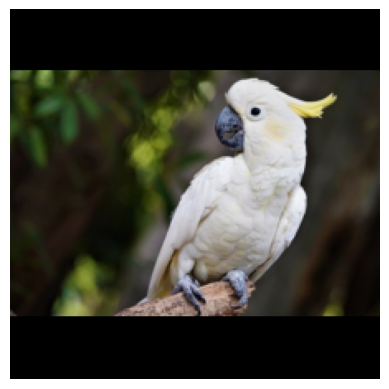

In [ ]:

def read_image_pytorch(file_name, target_size=224):
    # Leer y decodificar la imagen (equivale a tf.io.read_file + tf.io.decode_jpeg)
    # Retorna un tensor [Canales, Alto, Ancho] con valores uint8 (0-255)
    image = read_image(file_name)

    # Convertir a float32 y escalar a [0, 1] (equivale a tf.image.convert_image_dtype)
    image = image.to(torch.float32) / 255.0

    # Resize with pad (PyTorch no tiene una sola función para esto, así que lo replicamos)
    _, h, w = image.shape

    # Calcular la escala para mantener la relación de aspecto
    scale = target_size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    # Redimensionar (equivale a la primera parte de resize_with_pad)
    image = F.resize(image, [new_h, new_w], antialias=True)

    # Calcular cuánto relleno (padding) necesitamos en cada lado
    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    # Aplicar el padding (formato: [izquierda, arriba, derecha, abajo])
    image = F.pad(image, [pad_left, pad_top, pad_right, pad_bottom], fill=0.0)

    return image



mi_imagen=read_image_pytorch(img_path)

# Vamos a imprimir la imagen
# Reordenar las dimensiones de [Canales, Alto, Ancho] a [Alto, Ancho, Canales]
# permute(1, 2, 0) mueve el Alto (índice 1) al principio, Ancho (índice 2) al medio, y Canales (índice 0) al final.
imagen_para_mostrar = mi_imagen.permute(1, 2, 0)

# Convertimos el tensor de PyTorch a un array de NumPy
imagen_para_mostrar = imagen_para_mostrar.numpy()

# Mostramos la imagen
plt.imshow(imagen_para_mostrar)
plt.axis('off')
plt.show()

Ahora procedemos a cargar el modelo, al igual que antes, usaremos el modelo **Inception v1**

In [ ]:
#Cargamos el modelo:

weights = GoogLeNet_Weights.IMAGENET1K_V1
model = googlenet(weights=weights)

# Ponemos el modelo en modo evaluación.
model.eval()

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

Descargamos las etiquetas y generamos una función para ver las predicciones que el modelo hace sobre la imagen

In [ ]:
# Descargamos el archivo oficial de clases de ImageNet usado por PyTorch
url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
filename = 'imagenet_classes.txt'
urllib.request.urlretrieve(url, filename)

# Leemos el archivo y guardamos las etiquetas en una lista
with open(filename, "r") as f:
    imagenet_labels = [s.strip() for s in f.readlines()]

In [ ]:
def top_k_predictions_pytorch(img, k=3):
    # Expandir dimensiones (creamos un batch de tamaño 1) porque
    # para predecir hay que pasar batches
    image_batch = img.unsqueeze(0)

    # Inferencia: En PyTorch SIEMPRE usamos torch.no_grad() cuando
    # solo queremos predecir. Esto ahorra muchísima memoria y tiempo.
    with torch.no_grad():
        predictions = model(image_batch)

    #Aplicamos softmax
    # OJO: En PyTorch, las predicciones salen con forma [Batch, Clases].
    # Por tanto, el eje de las clases es dim=1.
    probs = torch.softmax(predictions, dim=1)

    # Obtener las probabilidades y los índices top K
    top_probs, top_idxs = torch.topk(probs, k)

    # Extraemos los datos (pasamos de tensores a listas estándar de Python)
    top_probs_list = top_probs[0].tolist()
    top_idxs_list = top_idxs[0].tolist()

    # Asociamos los índices a sus nombres reales
    top_labels = [imagenet_labels[i] for i in top_idxs_list]

    return top_labels, top_probs_list

In [ ]:
top_k_predictions_pytorch(mi_imagen,3)

(['sulphur-crested cockatoo', 'ptarmigan', 'spoonbill'],
 [0.9935157299041748, 0.001067348406650126, 0.000830327975563705])

Como era de esperar, sigue prediciendo cacatúa con un 0.99% de confianza

Pasamos ahora a aplicar ShapleyCAM, para ello vamos a usar la función `ShapleyCAM`, para ello hay que eliminar la última capa del modelo y finalmente tendremos que hacer el heatmap. Se puede encontrar más información sobre esto [aquí](https://github.com/caihuaiguang/pytorch-shapley-cam/tree/master/pytorch_grad_cam)

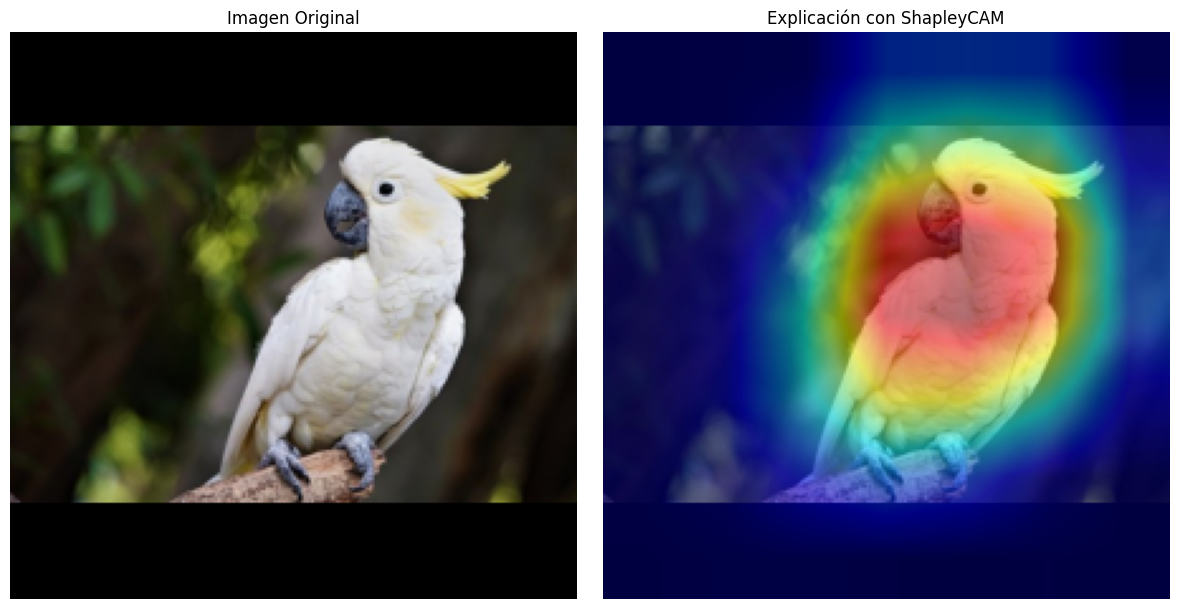

In [ ]:
# Añadimos la dimensión para hacer un batch de tamaño 1
input_tensor = mi_imagen.unsqueeze(0)

# Para la visualización final, necesitamos la imagen en formato numpy HWC (Alto, Ancho, Canales)
# así que permutamos
rgb_image_np = mi_imagen.permute(1, 2, 0).numpy()


# CONFIGURAMOS ShapleyCAM
# Elegimos la capa justo antes de la reducción final (Pooling)
target_layers = [model.inception5b]

# Inicializamos el explainer. Por defecto, usará la función ReST
# (Residual Softmax Target-Class) que proponen en el artículo para evitar
# el desvanecimiento de gradientes.
cam = ShapleyCAM(model=model, target_layers=target_layers)


# GENERAMOS EL MAPA DE CALOR (Heatmap)

# Si no le pasas 'targets', automáticamente explicará la clase
# con la probabilidad más alta (la predicción principal del modelo).
grayscale_cam = cam(input_tensor=input_tensor, targets=None)

# Tomamos el resultado de la primera imagen del batch
grayscale_cam = grayscale_cam[0, :]


# VISUALIZAMOS
# show_cam_on_image superpone el mapa de calor sobre tu imagen original
visualization = show_cam_on_image(rgb_image_np, grayscale_cam, use_rgb=True)



fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original en la izquierda
axs[0].imshow(rgb_image_np)
axs[0].set_title("Imagen Original")
axs[0].axis('off')

# Mapa de ShapleyCAM en la derecha
axs[1].imshow(visualization)
axs[1].set_title("Explicación con ShapleyCAM")
axs[1].axis('off')

plt.tight_layout()
plt.show()

Como cabía esperar, lo que más se resalta es a la propia cacatúa

## 3: Manipulación de explicaciones

Este apartado a diferencia de los anteriores no consiste en un método de explicabilidad. Aquí lo que se expone es **un método para manipular la explicabilidad** y que dé los resultados que queremos,añadiendo una perturbación casi invisible al ojo humano en una imagen de entrada. Todo este desarrollo se basa en la geometría.

### Explicación del método

Lo primero antes de desarrollar el método, debemos saber qué estamos buscando. Consideramos una red neuronal $g:\mathbb{R}^{d}\rightarrow\mathbb{R}^{K}$ con no linealidades ReLU que clasifica una imagen $x\in\mathbb{R}^{d}$ en K categorías con la clase predicha dada por $k=\arg\max_{i}g(x)_{i}$. Denotaremos al mapa de explicación como $h:\mathbb{R}^{d}\rightarrow\mathbb{R}^{d}$ y asocia cada imagen con un vector de la misma dimensión cuyos componentes son las relevancias de cada píxel para la predicción de la red neuronal.

Para un método de explicación dado y un objetivo específico $h^{t}\in\mathbb{R}^{d}$, queremos que una imagen manipulada $x_{adv}=x+\delta x$  (le hemos sumado un ruido $δ$ que queremos que sea imperceptible al ojo humano pero cambie la explicación y la predicción sea la misma) tiene las siguientes propiedades:


1.   La salida de la red se mantiene aproximadamente constante, es decir, $g(x_{adv})\approx g(x)$ (para que la predicción sea la misma).
2.   La explicación es cercana al mapa objetivo, es decir, $h(x_{adv})\approx h^{t}$ (para que esté manipulada como queremos).
3. La norma de la perturbación $\delta x$ añadida a la imagen de entrada es pequeña, es decir, $||\delta x||=||x_{adv}-x||\ll 1$ para que no sea perceptible al ojo humano.

Vamos a obtener la manipulación buscada minimizando la función de pérdida
$$\mathcal{L} = ||h(x_{adv}) - h^t||^2 + \gamma ||g(x_{adv}) - g(x)||^2$$
con respecto a $x_{adv}$ utilizando el descenso de gradiente (limitando los valores de $x_{adv}$ después de cada iteración para que sea una imagen válida). Vemos que la función pérdida que queremos minimizar no es más que la distancia euclídea entre
  $h(x_{adv}) - h^t$ y entre  $g(x_{adv}) - g(x)$ (buscamos que se parezcan para que se cumpla con lo dijimos antes). El hiperparámetro $\gamma \in \mathbb{R}_+$ controla a cuál de las dos partes le queremos dar más peso (si priorizamos que se conserve la predicción o la explicación sea la que queremos y por cuánto la priorizamos).
  
  Como usamos el gradiente para optimizar, el gradiente con respecto a la entrada $\nabla h(x)$ de la explicación suele requerir de la segunda derivada de la función ReLU, ya que muchos métodos de explicabilidad se basan en el gradiente. Esto da lugar a desvanecimiento (la segunda derivada de la función ReLU donde existe es 0). Esto, evidentemente causa problemas. $$\partial_{x_{adv}} ||h(x_{adv}) - h^t||^2 \propto \frac{\partial h}{\partial x_{adv}} = \frac{\partial^2 g}{\partial x_{adv}^2} \propto \text{relu}'' = 0 .$$

Para evitar este problema se reemplaza las función ReLU por softplus:$$softplus_{\beta}(x) = \frac{1}{\beta} \log(1 + e^{\beta x}).$$
Para valores grandes de $\beta$, la función softplus se aproxima mucho a la ReLU pero tiene una segunda derivada bien definida. Una vez completada la optimización, ya se prueba la imagen manipulada usando la ReLU original.



#### Justificación matemática (¡Geometría!)

Hemos dicho que queremos que a pesar de tener la imagen perturbada, que la predicción se mantenga igual, es decir

$$g(x)=g(x+\delta x) = c$$

Podemos considerar una hipersuperficie $\mathcal{S}=\{p \in \mathbb{R}^d\mid g(p)=c\}$. De hecho podemos solo considerar la clase ganadora que es la que nos interesa $g(x):=g(x)_k$ con $k=\operatorname{arg max}_i g(i)$ ya que los métodos que usan el gradiente es lo que usan.

El gradiente $\nabla g \quad \forall p \in \mathcal{S}$  es normal a la hipersuperficie. Y que el gradiente puede cambiar drásticamente simplemente moviendonos un poco en la superficie nos da la intuición de que esa superficie está "muy curvada", es decir, que su curvatura es grande (pensemos por ejemplo que si fuese un plano el vector normal sería constante todo el rato).

Para medir esta curvatura, tenemos que usar la segunda forma fundamental aunque para calcularla necesitamos elementos de geometría diferencial (vector normal, espacio tangente...)


Consideramos el vector normal normalizado, pues es más cómodo.
$$n(x) = \frac{\nabla g(x)}{||\nabla g(x)||} .$$

Para cualquier punto $p \in S$, podemos definir el espacio tangente $T_pS$ como el espacio vectorial abarcado por los vectores tangentes $\dot{\gamma}(0) = \frac{d}{dt}\gamma(t)|_{t=0}$ de todas las curvas posibles $\gamma : \mathbb{R} \rightarrow S$ con $\gamma(0) = p$. Para $u, v \in T_pS$, denotamos su producto escalar por $\langle u, v \rangle$. Para cualquier $u \in T_pS$, la derivada direccional está definida unívocamente independientemente de la elección de $\gamma$ por$$D_u f(p) = \frac{d}{dt} f(\gamma(t)) \bigg|_{t=0} \qquad \text{con} \qquad \gamma(0) = p \text{ y } \dot{\gamma}(0) = u .$$

A continuación, definimos la aplicación de Weingarten como
$$L : \begin{cases} T_pS \rightarrow T_pS \\ u \mapsto -D_u n(p) , \end{cases}$$

Esta aplicación cuantifica cuánto cambia el vector normal unitario a medida que nos alejamos infinitesimalmente de $p$ en la dirección $u$.
También tenemos sa segunda forma fundamental, que viene dada  por
$$\mathcal{L} : \begin{cases} T_pS \times T_pS \rightarrow \mathbb{R} \\ u, v \mapsto -\langle v, L(u) \rangle = -\langle v, D_u n(p) \rangle . \end{cases}$$

La segunda forma fundamental es bilineal y simétrica $\mathcal{L}(u, v) = \mathcal{L}(v, u)$. Por lo tanto, es diagonalizable con autovalores reales $\lambda_1, \dots, \lambda_{d-1}$ que se denominan **curvaturas principales**.Por lo tanto, hemos demostrado matemáticamente que la sensibilidad del mapa de explicabilidad con el uso del gradiente está descrita por las curvaturas principales, un concepto clave de la geometría diferencial.

En particular, esto nos permite buscar un límite superior de cuánto puede cambiar el mapa del gradiente como mucho $h(x) = n(x)$ a medida que nos movemos ligeramente sobre $S$. Para ello, definimos la distancia geodésica $d_g(p, q)$ de dos puntos $p, q \in S$ como la longitud de la curva más corta en $S$ que conecta $p$ y $q$.

Se llega así al **Teorema 1** del artículo:

Sea $g : \mathbb{R}^d \rightarrow \mathbb{R}$ una red con funciones no lineales $\text{softplus}_\beta$ y $\mathcal{U}_\epsilon(p) = \{x \in \mathbb{R}^d ; ||x - p|| < \epsilon\}$ un entorno de un punto $p \in S$ tal que $\mathcal{U}_\epsilon(p) \cap S$ es conexo. Sea $g$ con derivadas acotadas $||\nabla g(x)|| \ge c$ para todo $x \in \mathcal{U}_\epsilon(p) \cap S$. Entonces se sigue que para todo $p_0 \in \mathcal{U}_\epsilon(p) \cap S$
$$||h(p) - h(p_0)|| \le |\lambda_{max}| d_g(p, p_0) \le \beta C d_g(p, p_0) , $$
donde $\lambda_{max}$ es la curvatura principal con el mayor valor absoluto para cualquier punto en $\mathcal{U}_\epsilon(p) \cap S$ y la constante $C > 0$ depende de los pesos de la red neuronal.

Este teorema se puede entedner intuitivamente de la siguiente manera: para las funciones ReLU, como son no lineales y hay puntos no derivables, esto hace que se produzcan pliegues, es decir, puntos donde la curvatura se hace enorme. Por otro lado, las funciones ReLU se aproximan bien por las funciones softplus con un $\beta$ grande. Reducir $\beta$ suaviza los pliegues y, por lo tanto, conduce a una curvatura máxima reducida, es decir, $|\lambda_{max}| \le \beta C$.

Para cada punto en la curva geodésica que conecta $p$ y $p_0$, la normal puede en el peor de los casos verse afectada por la curvatura máxima, es decir, el cambio en la explicación está acotado por $|\lambda_{max}| d_g(p, p_0)$.

De este teorema podemos aprender que como  la distancia geodésica puede ser bastante mayor que la distancia euclídea para variedades curvas, las entradas que son muy similares entre sí, donde la distancia euclidiana es pequeña, pueden tener explicaciones que son drásticamente diferentes. Por otro lado, para acotar este cambio de explicación, sabemos que el límite superior de la distancia de las explicaciones es proporcional al parámetro $\beta$ de la no linealidad softplus. Por lo tanto, valores más pequeños de $\beta$ resultan demostrablemente en una mayor robustez con respecto a las manipulaciones.

### Ejemplo práctico (cacatúa)

Primero cargamos las librerias que vamos a utilizar en este apartado

In [ ]:
import torch
from torchvision.io import read_image
from torchvision.models import googlenet, GoogLeNet_Weights
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

Cargamos Drive para importar las imágenes

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')
%cd 'drive/MyDrive/SAAA_2026'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: 'drive/MyDrive/SAAA_2026'
/content/drive/MyDrive/SAAA_2026


In [ ]:
img_path = './cockatoo.jpeg'

Definimos una función para procesar las imágenes

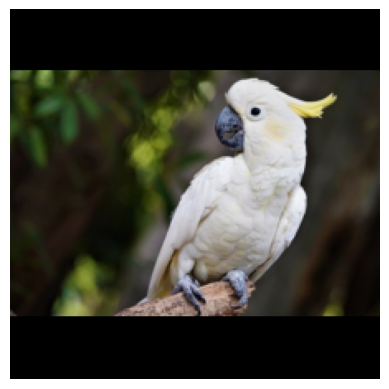

In [ ]:
def read_image_pytorch(file_name, target_size=224):

    image = read_image(file_name)

    image = image.to(torch.float32) / 255.0

    _, h, w = image.shape

    scale = target_size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    image = F.resize(image, [new_h, new_w], antialias=True)

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    image = F.pad(image, [pad_left, pad_top, pad_right, pad_bottom], fill=0.0)

    return image



mi_imagen=read_image_pytorch(img_path)

# Vamos a imprimir la imagen
# Reordenar las dimensiones de [Canales, Alto, Ancho] a [Alto, Ancho, Canales]
# permute(1, 2, 0) mueve el Alto (índice 1) al principio, Ancho (índice 2) al medio, y Canales (índice 0) al final.
imagen_para_mostrar = mi_imagen.permute(1, 2, 0)

# Convertimos el tensor de PyTorch a un array de NumPy
imagen_para_mostrar = imagen_para_mostrar.numpy()

# Mostramos la imagen
plt.imshow(imagen_para_mostrar)
plt.axis('off')
plt.show()

Ahora cargamos el modelo

In [ ]:
#Cargamos el modelo:

weights = GoogLeNet_Weights.IMAGENET1K_V1
model = googlenet(weights=weights)

# Ponemos el modelo en modo evaluación.
modelo = model.eval()

También cargamos las etiquetas y definimos una función para ver las predicciones

In [ ]:
# Descargamos el archivo oficial de clases de ImageNet usado por PyTorch
url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
filename = 'imagenet_classes.txt'
urllib.request.urlretrieve(url, filename)

# Leemos el archivo y guardamos las etiquetas en una lista
with open(filename, "r") as f:
    imagenet_labels = [s.strip() for s in f.readlines()]

In [ ]:
def top_k_predictions_pytorch(img, k=3):
    image_batch = img.unsqueeze(0)

    with torch.no_grad():
        predictions = model(image_batch)

    probs = torch.softmax(predictions, dim=1)


    top_probs, top_idxs = torch.topk(probs, k)


    top_probs_list = top_probs[0].tolist()
    top_idxs_list = top_idxs[0].tolist()


    top_labels = [imagenet_labels[i] for i in top_idxs_list]

    return top_labels, top_probs_list

Definimos algunas funciones auxiliares para calcular los mapas de calor de explicabilidad (usando gradientes)

In [ ]:
#realizamos la normalización recomendada para nuestro modelo
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def forward_pass(img_tensor, net):
    img_norm = img_tensor.clone()
    img_norm[0] = normalize(img_norm[0])
    return net(img_norm)

def get_gradient_explanation(img_tensor, net):
    if not img_tensor.requires_grad:
        img_tensor.requires_grad_(True)

    logits = forward_pass(img_tensor, net)
    target_class = logits.argmax(dim=1)
    score = logits[0, target_class]

    # Calculamos el gradiente
    gradients = torch.autograd.grad(outputs=score, inputs=img_tensor,
                                    create_graph=True)[0]
    heatmap = gradients.abs().sum(dim=1, keepdim=True)

    # Normalización del paper
    suma = heatmap.sum() + 1e-8
    heatmap = heatmap / suma

    return heatmap, logits


También hacemos funciones auxiliares para ayudarnos a visualizar

In [ ]:
def tensor_to_img(tensor):
    # Convierte de [1, C, H, W] a [H, W, C] para matplotlib
    return tensor.squeeze(0).permute(1, 2, 0).detach().numpy()

def tensor_to_heatmap(tensor):
    # Elimina dimensiones extra para dejar un array 2D
    return tensor.squeeze().detach().numpy()

In [ ]:
top_k_predictions_pytorch(mi_imagen,3)

(['sulphur-crested cockatoo', 'ptarmigan', 'spoonbill'],
 [0.9935157299041748, 0.001067348406650126, 0.000830327975563705])

Vemos ahora una comparativa entre las dos imagenes que vamos a usar y sus mapas de explicación

Procesando imágenes y extrayendo explicaciones...
Predicciones de la imágen original (['sulphur-crested cockatoo', 'ptarmigan', 'spoonbill'], [0.9935157299041748, 0.001067348406650126, 0.000830327975563705]) 

Predicciones de la imágen a copiar (['goldfish', 'tench', 'rock beauty'], [0.994151771068573, 0.0015093864640221, 0.0007262109429575503]) 



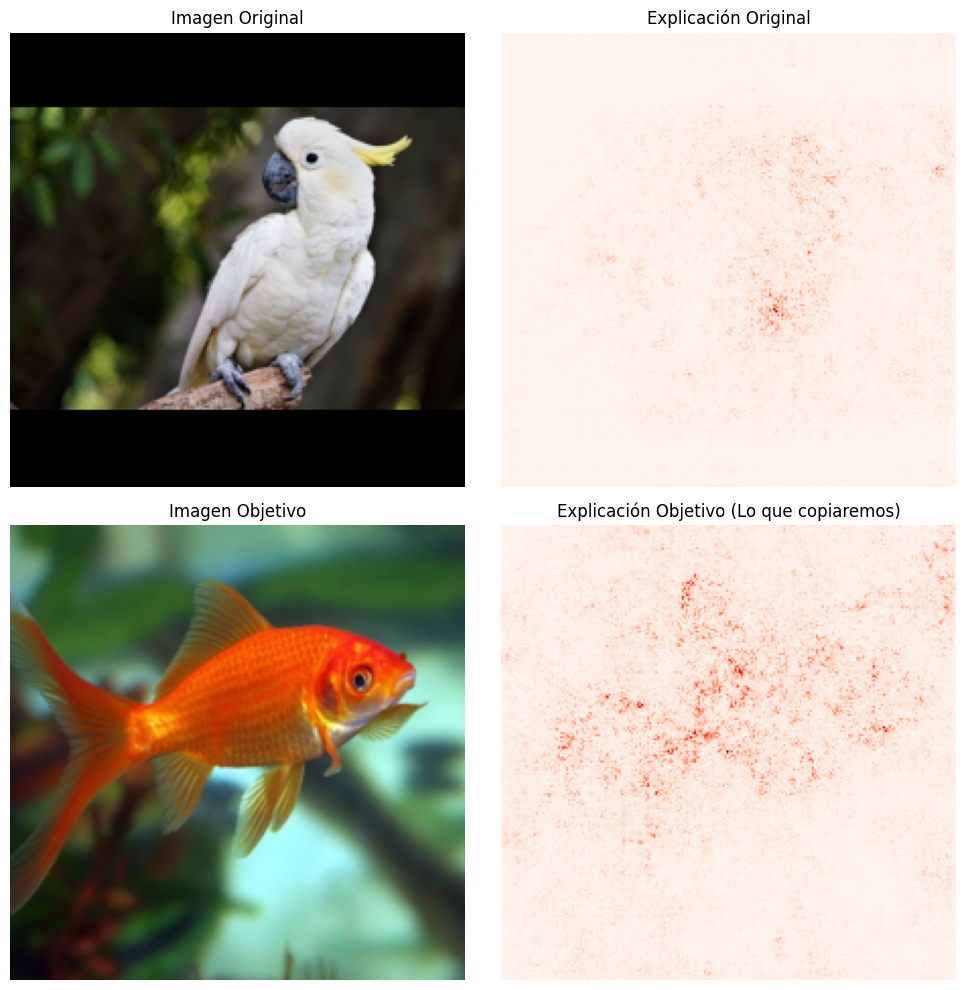

In [ ]:
ruta_original = "cockatoo.jpeg"
ruta_objetivo = "goldfish.jpg"

print("Procesando imágenes y extrayendo explicaciones...")
x_orig = read_image_pytorch(ruta_original)
x_target = read_image_pytorch(ruta_objetivo)

print("Predicciones de la imágen original" ,top_k_predictions_pytorch(x_orig,3)
                                                              ,"\n")
print("Predicciones de la imágen a copiar" ,top_k_predictions_pytorch(x_target,3),
      "\n")

x_orig=x_orig.unsqueeze(0)
x_target=x_target.unsqueeze(0)

# Extraemos los mapas de explicación con el modelo
h_orig, _ = get_gradient_explanation(x_orig, modelo)
h_target, _ = get_gradient_explanation(x_target, modelo)



fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Fila 1: Imagen original y su explicación
axes[0, 0].imshow(tensor_to_img(x_orig))
axes[0, 0].set_title("Imagen Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(tensor_to_heatmap(h_orig), cmap='Reds')
axes[0, 1].set_title("Explicación Original")
axes[0, 1].axis('off')

# Fila 2: Imagen objetivo y su explicación
axes[1, 0].imshow(tensor_to_img(x_target))
axes[1, 0].set_title("Imagen Objetivo")
axes[1, 0].axis('off')

axes[1, 1].imshow(tensor_to_heatmap(h_target), cmap='Reds')
axes[1, 1].set_title("Explicación Objetivo (Lo que copiaremos)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Con todos nuestros ingredientes preparados, podemos pasar a hacer el algoritmo para manipular la explicación visto en el paper. Lo primero que hay que tener en cuenta es que hay que reemplazar la función ReLU por una **softplus** (para que se puedan hacer segundas derivadas)

Iniciando ataque...
Iteración    0 | Loss Expl (Escalada): 41.4978 | Loss Pred: 7.470060
Iteración  100 | Loss Expl (Escalada): 18.5231 | Loss Pred: 0.320113
Iteración  200 | Loss Expl (Escalada): 16.7882 | Loss Pred: 0.403154
Iteración  300 | Loss Expl (Escalada): 16.3662 | Loss Pred: 0.260193
Iteración  400 | Loss Expl (Escalada): 15.6745 | Loss Pred: 0.375503
Iteración  500 | Loss Expl (Escalada): 15.1954 | Loss Pred: 0.247455
Iteración  600 | Loss Expl (Escalada): 14.8137 | Loss Pred: 0.251864
Iteración  700 | Loss Expl (Escalada): 14.4929 | Loss Pred: 0.228243
Iteración  800 | Loss Expl (Escalada): 14.4979 | Loss Pred: 0.280246
Iteración  900 | Loss Expl (Escalada): 14.5080 | Loss Pred: 0.229064
Iteración 1000 | Loss Expl (Escalada): 14.3607 | Loss Pred: 0.252664
Iteración 1100 | Loss Expl (Escalada): 14.0649 | Loss Pred: 0.218706
Iteración 1200 | Loss Expl (Escalada): 13.9790 | Loss Pred: 0.203224
Iteración 1300 | Loss Expl (Escalada): 13.8090 | Loss Pred: 0.242858
Iteración 1400

Iteración 1499 | Loss Expl (Escalada): 13.8598 | Loss Pred: 0.292281
¡Ataque completado!


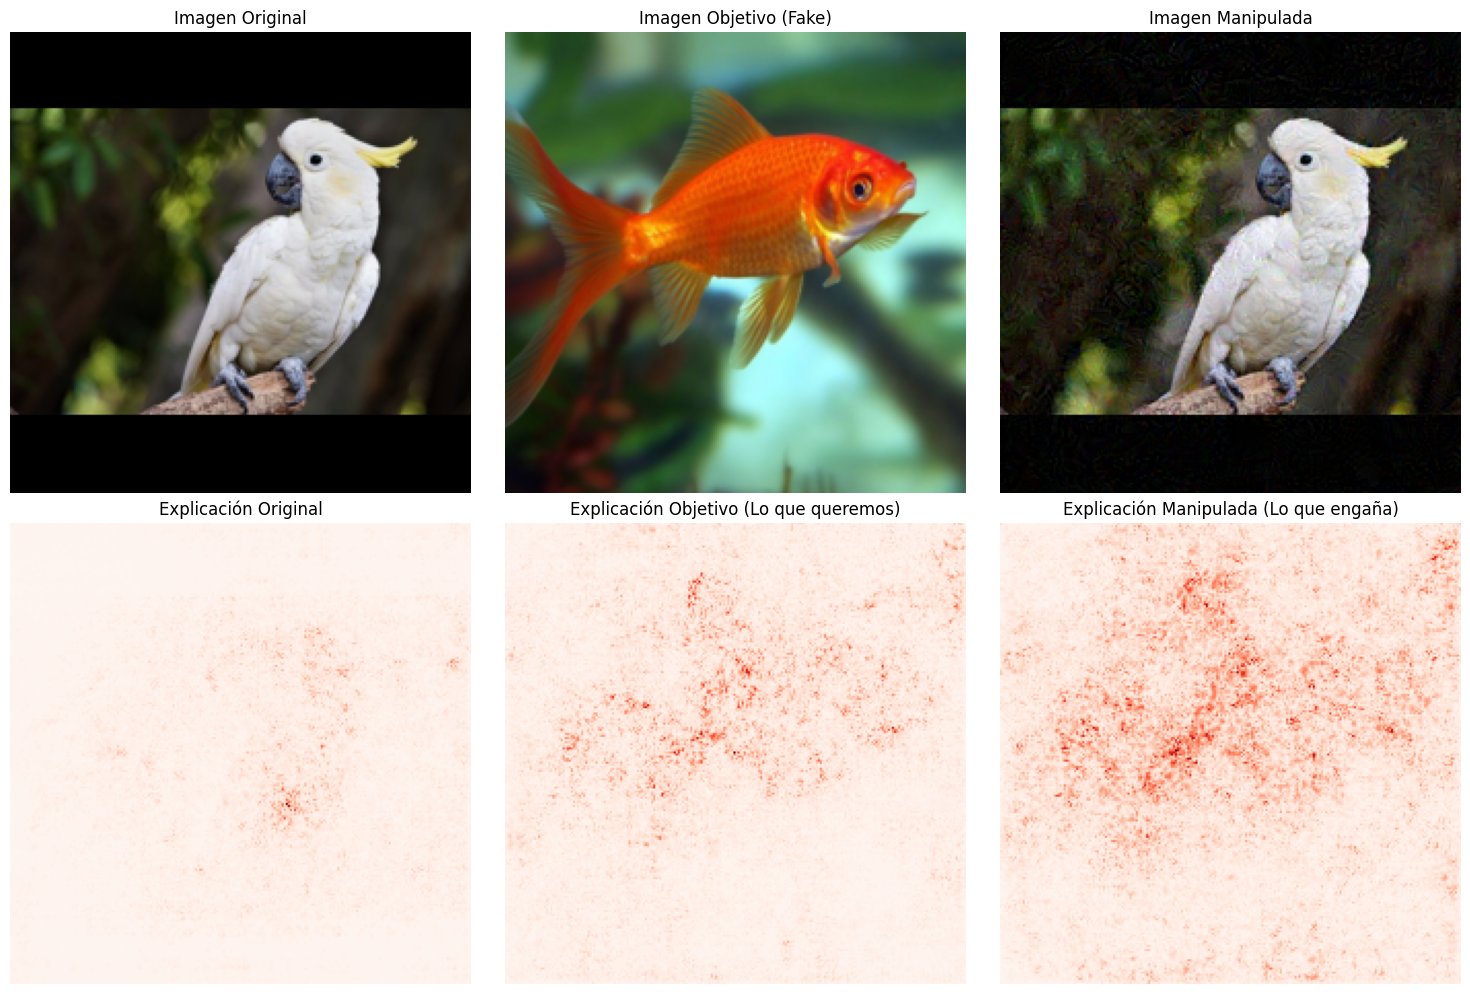

In [ ]:
#Hacemos una copia del modelo para usarlo en el ataque solo (vamos a
# sustituir la ReLU por softplus)

modelo_ataque = copy.deepcopy(modelo)


import types
from torchvision.models.googlenet import BasicConv2d
import torch.nn.functional as F

def replace_relu_with_softplus(net, beta=10.0):
    """Reemplaza ReLUs en GoogLeNet inyectando un nuevo forward en los bloques BasicConv2d"""
    def make_new_forward(beta_val):
        def new_forward(self, x):
            x = self.conv(x)
            x = self.bn(x)
            # Reemplazamos el F.relu original por F.softplus
            return F.softplus(x, beta=beta_val)
        return new_forward

    for child_name, child in net.named_children():
        # Si es un bloque interno de GoogLeNet, le parcheamos el forward
        if isinstance(child, BasicConv2d):
            child.forward = types.MethodType(make_new_forward(beta), child)
        # Si es una capa nn.ReLU normal (por si acaso hubiera alguna)
        elif isinstance(child, nn.ReLU):
            setattr(net, child_name, nn.Softplus(beta=beta))
        # Si es otro bloque (ej. Inception), navegamos recursivamente
        else:
            replace_relu_with_softplus(child, beta)

# Aplicamos el parche SOLO al modelo de ataque
replace_relu_with_softplus(modelo_ataque, beta=10.0)


# Mapas estáticos
h_t, _ = get_gradient_explanation(x_target, modelo)
h_t = h_t.detach()

# Calculamos la explicación original normalmente (necesita gradientes activos)
h_orig, logits_orig = get_gradient_explanation(x_orig, modelo)

# Ahora  los "congelamos" para usarlos como objetivos estáticos en tu bucle
h_orig = h_orig.detach()
logits_orig = logits_orig.detach()

# BUCLE DE OPTIMIZACIÓN
x_adv = x_orig.clone().detach().requires_grad_(True)
# Hiperparámetros basados en el Apéndice A del paper
optimizer = optim.Adam([x_adv], lr=0.001)

# FACTORES DE ESCALADO CLAVE
# Multiplicamos la pérdida de la explicación por un millón para que
# los gradientes sean lo bastante grandes como para modificar la imagen.
factor_expl = 1e6
gamma = 1.0 # Como ya hemos escalado la explicación, mantenemos la predicción a escala normal

iteraciones = 1500

print("Iniciando ataque...")




for i in range(iteraciones):
    optimizer.zero_grad()

    h_x_adv, logits_adv = get_gradient_explanation(x_adv, modelo_ataque)

    # Calculamos el MSE base
    # Usamos reduction='sum' para que haga la Suma de Errores al Cuadrado (norma L2)
    # tal y como está escrito en la fórmula original del paper.
    loss_expl = torch.nn.functional.mse_loss(h_x_adv, h_t, reduction='sum')
    loss_pred = torch.nn.functional.mse_loss(logits_adv, logits_orig, reduction='sum')

    # Aplicamos los multiplicadores antes del backward
    loss_total = (factor_expl * loss_expl) + (gamma * loss_pred)

    loss_total.backward()
    optimizer.step()

    with torch.no_grad():
        x_adv.clamp_(0, 1)

    if i % 100 == 0 or i == iteraciones - 1:
        # Imprimimos los valores
        print(f"Iteración {i:4d} | Loss Expl (Escalada): {factor_expl * loss_expl.item():.4f} | Loss Pred: {loss_pred.item():.6f}")

print("¡Ataque completado!")

# VISUALIZACION DE RESULTADOS

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Fila superior: Imágenes
axes[0, 0].imshow(tensor_to_img(x_orig))
axes[0, 0].set_title("Imagen Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(tensor_to_img(x_target))
axes[0, 1].set_title("Imagen Objetivo (Fake)")
axes[0, 1].axis('off')

axes[0, 2].imshow(tensor_to_img(x_adv))
axes[0, 2].set_title("Imagen Manipulada")
axes[0, 2].axis('off')

# Fila inferior: Mapas de explicación
# Usamos el colormap 'hot' o 'Reds' para simular los mapas de calor del artículo
axes[1, 0].imshow(tensor_to_heatmap(h_orig), cmap='Reds')
axes[1, 0].set_title("Explicación Original")
axes[1, 0].axis('off')

axes[1, 1].imshow(tensor_to_heatmap(h_t), cmap='Reds')
axes[1, 1].set_title("Explicación Objetivo (Lo que queremos)")
axes[1, 1].axis('off')

h_adv_final, _ = get_gradient_explanation(x_adv, modelo)
axes[1, 2].imshow(tensor_to_heatmap(h_adv_final), cmap='Reds')
axes[1, 2].set_title("Explicación Manipulada (Lo que engaña)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Vemos que nuestra manipulación ha funcionado. Por último, veamos que la predicción de la imagen modificada sigue siendo correcta

In [ ]:
top_k_predictions_pytorch(x_adv.squeeze(0),3)

(['sulphur-crested cockatoo', 'ptarmigan', 'African grey'],
 [0.9971365928649902, 0.0005468629533424973, 0.0005025521386414766])